# experiment analyzer

here i need to plot for gcns: CCC / RMSE relative to persistence, per horizon. I believe the distance gros.

I need to plot the same for GCNLSTM and GATv2 to see hwether that holds.

In [1]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import wilcoxon
import scipy.stats

from src.utils.helpers import get_wissdaten_env
from src.dataloading.epiconfig import EpiConfig
from src.dataloading.epidataorchestration import EpiDataOrchestrator
from src.dataloading.dataloaders import BaseLineDataLoaderManager
from src.models import PersistenceModel, ClimateologyModel, ClimaScaleModel
from src.models.deep.deepmodel import DeepModel
from src.evaluation import Evaluator


# ═══════════════════════════════════════════════════════════════════════════
# 1. EVALUATION
# ═══════════════════════════════════════════════════════════════════════════

def evaluate_experiment(
    experiment_subdir:  str,
    base_config:        dict,
    horizon_leadtimes:  list,
) -> pd.DataFrame:
    """
    Load saved models, forecast, evaluate.
    Returns flat metrics dataframe with columns:
    horizon, seed, model, node, ccc, mae, ...
    """
    all_metrics = []

    for hl in horizon_leadtimes:
        print(f"\n── hl={hl} ──────────────────────────────────────")

        cfg       = EpiConfig(horizon_leadtime=hl, **base_config)
        data_orch = EpiDataOrchestrator(cfg).build()

        baseline_dlm = BaseLineDataLoaderManager(data_orch)
        persistence  = PersistenceModel(baseline_dlm,  f'persistence_hl{hl}')
        climatology  = ClimateologyModel(baseline_dlm, f'climateology_hl{hl}')
        climascale   = ClimaScaleModel(baseline_dlm,   f'climascale_hl{hl}')
        persistence.forecast('test')
        climatology.forecast('test')
        climascale.forecast('test')
        baselines = [persistence, climatology, climascale]

        absolute_path = os.path.join(get_wissdaten_env(),'project_utilities/infectious_disease_gnn/models', experiment_subdir)

        hl_files = [
            f for f in os.listdir(absolute_path)
            if f.endswith('.pt') and f'_hl{hl}_' in f
        ]

        if not hl_files:
            print(f"  no files for hl={hl}, skipping")
            continue

        seed_pattern = re.compile(r'_s(\d+)\.pt$')
        seeds_found  = sorted(set(
            int(seed_pattern.search(f).group(1))
            for f in hl_files if seed_pattern.search(f)
        ))
        print(f"  seeds: {seeds_found}")

        for seed in seeds_found:
            seed_files  = [f for f in hl_files if f'_s{seed}.pt' in f]
            deep_models = []

            for modelfile in seed_files:
                name = modelfile.replace('.pt', '')
                try:
                    model = DeepModel.load(name, experiment_subdir)
                    model.forecast('test')
                    deep_models.append(model)
                except Exception as e:
                    print(f"  failed: {name} — {e}")
                    continue

            if not deep_models:
                continue

            all_models = baselines + deep_models
            evaluator  = Evaluator(all_models)
            evaluator.add_evaluation(horizon=0, dataset='test')

            metrics            = evaluator.data_compilation.get_data(0, 'test')['metrics'].copy()
            metrics['horizon'] = hl
            metrics['seed']    = seed
            metrics['model']   = (
                metrics['model'].astype(str)
                .str.replace(f'_hl{hl}_s{seed}', '', regex=False)
                .str.replace(f'_hl{hl}',         '', regex=False)
            )

            all_metrics.append(metrics)
            del evaluator, deep_models, all_models
            print(f"  seed={seed} done")

        del data_orch

    return pd.concat(all_metrics, ignore_index=True)


# ═══════════════════════════════════════════════════════════════════════════
# 2. SUMMARISE
# ═══════════════════════════════════════════════════════════════════════════

def summarise_from_metrics_df(
    metrics_df: pd.DataFrame,
    metric:     str = 'ccc',
):
    """
    Aggregate metric across seeds per model per horizon.
    Std is computed across seed means, not raw node observations.

    Returns
    -------
    per_seed : mean per (horizon, model, seed)
    summary  : mean ± std across seeds per (horizon, model)
    """
    pers = (
        metrics_df[metrics_df['model'] == 'persistence']
        .groupby('horizon')[metric]
        .mean()
        .rename('pers_mean')
    )

    df                     = metrics_df.merge(pers, on='horizon')
    df[f'{metric}_delta']  = df[metric] - df['pers_mean']

    # step 1: average across nodes within each seed
    per_seed = (
        df.groupby(['horizon', 'model', 'seed'])
        [[metric, f'{metric}_delta']]
        .mean()
        .reset_index()
    )

    # step 2: aggregate across seeds
    summary = (
        per_seed.groupby(['horizon', 'model'])
        .agg(
            mean       = (metric,            'mean'),
            std        = (metric,            'std'),
            mean_delta = (f'{metric}_delta', 'mean'),
            std_delta  = (f'{metric}_delta', 'std'),
        )
        .round(4)
        .reset_index()
    )

    return per_seed, summary


def print_summary_table(summary: pd.DataFrame, metric: str = 'ccc'):
    pivot = summary.pivot_table(
        index='model', columns='horizon', values='mean_delta'
    ).round(4)
    print(f"\n── Mean {metric} delta over persistence ──────────────────────")
    print(pivot.to_string())

    pivot_std = summary.pivot_table(
        index='model', columns='horizon', values='std_delta'
    ).round(4)
    print(f"\n── Std across seeds ──────────────────────────────────────────")
    print(pivot_std.to_string())


# ═══════════════════════════════════════════════════════════════════════════
# 3. GRAPH STRUCTURE EFFECT PLOT
# ═══════════════════════════════════════════════════════════════════════════

def plot_graph_structure_effect(
    per_seed:           pd.DataFrame,
    models_to_compare:  dict,
    metric:             str = 'ccc',
    title:              str = 'Graph structure effect across horizons',
):
    """
    Plots within-architecture gap between graph types across horizons.

    models_to_compare: dict of label -> (model_a, model_b)
        plotted value = model_a metric - model_b metric
    """
    palette = {
        'geo − identity'    : '#2196F3',
        'geo − random'      : '#4CAF50',
        'commuter − random' : '#FF9800',
        'geo − lstm'        : '#9C27B0',
    }

    horizons = sorted(per_seed['horizon'].unique())
    seeds    = sorted(per_seed['seed'].unique())

    gap_records = []
    for label, (model_a, model_b) in models_to_compare.items():
        for hl in horizons:
            for seed in seeds:
                row_a = per_seed[
                    (per_seed['horizon'] == hl) &
                    (per_seed['seed']    == seed) &
                    (per_seed['model']   == model_a)
                ]
                row_b = per_seed[
                    (per_seed['horizon'] == hl) &
                    (per_seed['seed']    == seed) &
                    (per_seed['model']   == model_b)
                ]
                if row_a.empty or row_b.empty:
                    continue

                gap_records.append({
                    'horizon' : hl,
                    'seed'    : seed,
                    'label'   : label,
                    'gap'     : row_a[metric].values[0] - row_b[metric].values[0],
                })

    gap_df = pd.DataFrame(gap_records)
    gap_summary = (
        gap_df.groupby(['horizon', 'label'])['gap']
        .agg(mean='mean', std='std')
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(10, 5))

    for label in models_to_compare:
        sub   = gap_summary[gap_summary['label'] == label].sort_values('horizon')
        color = palette.get(label, 'black')

        ax.plot(sub['horizon'], sub['mean'],
                label=label, color=color, marker='o', linewidth=2)
        ax.fill_between(
            sub['horizon'],
            sub['mean'] - sub['std'],
            sub['mean'] + sub['std'],
            color=color, alpha=0.12
        )

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_xlabel('Forecast horizon (weeks ahead)', fontsize=12)
    ax.set_ylabel(f'Δ {metric.upper()} (positive = first model better)', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.legend(fontsize=10, framealpha=0.9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("\n── Gap means ────────────────────────────────────────────────")
    print(gap_summary.pivot_table(
        index='label', columns='horizon', values='mean'
    ).round(4).to_string())

    return fig, gap_df, gap_summary


# ═══════════════════════════════════════════════════════════════════════════
# 4. WILCOXON
# ═══════════════════════════════════════════════════════════════════════════

def node_level_significance(
    metrics_df:         pd.DataFrame,
    completed_horizons: list,
    model_a:            str = 'gcn_geo',
    model_b:            str = 'gcn_identity',
    metric:             str = 'ccc',
):
    """Paired Wilcoxon test on node-level metric across seeds."""
    records = []

    for hl in completed_horizons:
        hl_df = metrics_df[metrics_df['horizon'] == hl].copy()
        hl_df['node'] = hl_df['node'].astype(int)

        seeds = sorted(hl_df['seed'].unique())
        a_values, b_values = [], []

        for seed in seeds:
            seed_df = hl_df[hl_df['seed'] == seed]

            a = seed_df[seed_df['model'] == model_a].set_index('node')[metric]
            b = seed_df[seed_df['model'] == model_b].set_index('node')[metric]

            common = a.index.intersection(b.index)
            if len(common) == 0:
                continue

            a_values.append(a.loc[common].values)
            b_values.append(b.loc[common].values)

        if not a_values:
            continue

        a_all = np.concatenate(a_values)
        b_all = np.concatenate(b_values)
        diffs = a_all - b_all
        diffs = diffs[~np.isnan(diffs)]

        if len(diffs) == 0 or np.all(diffs == 0):
            continue

        stat, p     = wilcoxon(diffs, alternative='greater')
        median_diff = np.median(diffs)

        records.append({
            'horizon':     hl,
            'model_a':     model_a,
            'model_b':     model_b,
            'n':           len(diffs),
            'W':           stat,
            'p':           p,
            'median_diff': median_diff,
            'significant': p < 0.05,
        })

        sig = '*' if p < 0.05 else ''
        print(f"hl={hl:2d} | {model_a} vs {model_b} | "
              f"n={len(diffs)}  W={stat:.0f}  p={p:.4f}  "
              f"median_diff={median_diff:+.4f}  {sig}")

    return pd.DataFrame(records)


# ═══════════════════════════════════════════════════════════════════════════
# 5. DEGRADATION RATE
# ═══════════════════════════════════════════════════════════════════════════

def degradation_rate(summary: pd.DataFrame, metric: str = 'ccc'):
    """Linear regression of mean_delta vs horizon per model."""
    records = []

    for model in summary['model'].unique():
        sub = summary[summary['model'] == model].sort_values('horizon')
        if len(sub) < 3:
            continue

        slope, intercept, r, p, se = scipy.stats.linregress(
            sub['horizon'], sub['mean_delta']
        )
        records.append({
            'model'    : model,
            'slope'    : round(slope, 4),
            'intercept': round(intercept, 4),
            'r2'       : round(r**2, 3),
            'p'        : round(p, 4),
        })
        print(f"{model:25s}  slope={slope:+.4f}  r²={r**2:.3f}  p={p:.4f}")

    return pd.DataFrame(records).sort_values('slope', ascending=False)


# ═══════════════════════════════════════════════════════════════════════════
# 6. RELATIVE RMSE
# ═══════════════════════════════════════════════════════════════════════════

def relative_rmse_table(
    metrics_df: pd.DataFrame,
    models:     list = None,
):
    """Mean and median % RMSE change vs persistence per model per horizon."""
    from sklearn.metrics import mean_squared_error

    if models is None:
        models = [m for m in metrics_df['model'].unique() if m != 'persistence']

    # persistence rmse per horizon per seed per node — need original preds
    # this version works from the metrics_df if rmse is already computed
    if 'rmse' not in metrics_df.columns:
        print("rmse column not found in metrics_df — skipping")
        return None

    pers_rmse = (
        metrics_df[metrics_df['model'] == 'persistence']
        .groupby(['horizon', 'seed', 'node'])['rmse']
        .mean()
        .reset_index()
        .rename(columns={'rmse': 'pers_rmse'})
    )

    df = metrics_df[metrics_df['model'].isin(models)].merge(
        pers_rmse, on=['horizon', 'seed', 'node']
    )
    df['rmse_rel'] = (df['rmse'] - df['pers_rmse']) / df['pers_rmse'] * 100

    # winsorise
    lo = df['rmse_rel'].quantile(0.01)
    hi = df['rmse_rel'].quantile(0.99)
    df['rmse_rel_w'] = df['rmse_rel'].clip(lo, hi)

    for stat, label in [('rmse_rel', 'Median'), ('rmse_rel_w', 'Winsorised mean')]:
        agg  = 'median' if stat == 'rmse_rel' else 'mean'
        pivot = (df.groupby(['horizon', 'model'])[stat]
                 .agg(agg)
                 .unstack('model')
                 .loc[:, [m for m in models if m in df['model'].unique()]]
                 .round(1))
        print(f"\n── {label} % RMSE vs persistence (negative = better) ──")
        print(pivot.to_string())

    return df


── hl=1 ──────────────────────────────────────
  seeds: [8, 21, 42, 123, 456]
✓ Model loaded: lstm_hl1_s8.pt
✓ Model loaded: gcn_random_hl1_s8.pt
✓ Model loaded: gcn_geo_hl1_s8.pt
✓ Model loaded: gcn_identity_hl1_s8.pt
✓ Model loaded: gcn_commuter_hl1_s8.pt


computing metrics nodewise: 100%|████████████████████████████████████████████████████████| 3200/3200 [00:03<00:00, 809.96it/s]


  seed=8 done
✓ Model loaded: gcn_geo_hl1_s21.pt
✓ Model loaded: gcn_random_hl1_s21.pt
✓ Model loaded: gcn_commuter_hl1_s21.pt
✓ Model loaded: gcn_identity_hl1_s21.pt
✓ Model loaded: lstm_hl1_s21.pt


computing metrics nodewise: 100%|████████████████████████████████████████████████████████| 3200/3200 [00:03<00:00, 804.23it/s]


  seed=21 done
✓ Model loaded: gcn_identity_hl1_s42.pt
✓ Model loaded: gcn_geo_hl1_s42.pt
✓ Model loaded: gatv2lstm_geo_hl1_s42.pt
✓ Model loaded: gcn_commuter_hl1_s42.pt
✓ Model loaded: gcnlstm_identity_hl1_s42.pt
✓ Model loaded: gcnlstm_geo_hl1_s42.pt
✓ Model loaded: gatv2lstm_commuter_hl1_s42.pt
✓ Model loaded: gcnlstm_random_hl1_s42.pt
✓ Model loaded: lstm_hl1_s42.pt
✓ Model loaded: gatv2lstm_identity_hl1_s42.pt
✓ Model loaded: gcn_random_hl1_s42.pt
✓ Model loaded: gatv2lstm_random_hl1_s42.pt
✓ Model loaded: gcnlstm_commuter_hl1_s42.pt


...

  seed=42 done
✓ Model loaded: gcn_geo_hl7_s123.pt
✓ Model loaded: gcn_random_hl7_s123.pt
✓ Model loaded: gcn_commuter_hl7_s123.pt
✓ Model loaded: gcn_identity_hl7_s123.pt
✓ Model loaded: lstm_hl7_s123.pt


computing metrics nodewise: 100%|████████████████████████████████████████████████████████| 3200/3200 [00:03<00:00, 804.58it/s]


  seed=123 done
✓ Model loaded: lstm_hl7_s456.pt
✓ Model loaded: gcn_random_hl7_s456.pt
✓ Model loaded: gcn_geo_hl7_s456.pt
✓ Model loaded: gcn_identity_hl7_s456.pt
✓ Model loaded: gcn_commuter_hl7_s456.pt


computing metrics nodewise: 100%|████████████████████████████████████████████████████████| 3200/3200 [00:04<00:00, 797.93it/s]


  seed=456 done

── Mean ccc delta over persistence ──────────────────────
horizon            1       2       3       4       5       6       7
model                                                               
climascale    0.0040  0.0706  0.1667  0.2736  0.3730  0.4606  0.5395
climateology -0.0229  0.0852  0.2180  0.3495  0.4872  0.6262  0.7492
gcn_commuter  0.0323  0.1017  0.2160  0.3436  0.4726  0.5986  0.7078
gcn_geo       0.0351  0.1029  0.2203  0.3536  0.4871  0.6150  0.7248
gcn_identity  0.0212  0.0878  0.1985  0.3213  0.4455  0.5649  0.6696
gcn_random    0.0252  0.0890  0.2093  0.3396  0.4696  0.6015  0.7120
lstm          0.0300  0.1013  0.2175  0.3424  0.4704  0.5873  0.6795
persistence   0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000

── Std across seeds ──────────────────────────────────────────
horizon            1       2       3       4       5       6       7
model                                                               
climascale    0.0000  0.0000  0.0

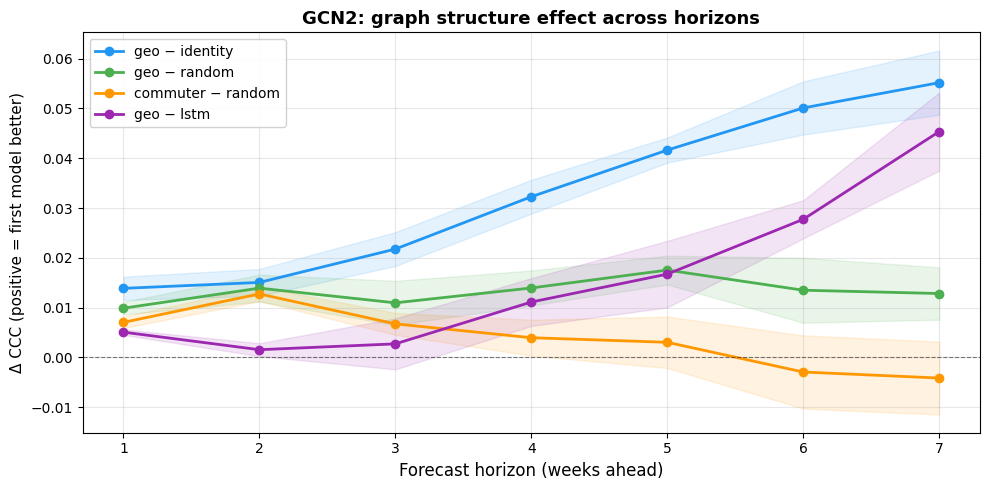


── Gap means ────────────────────────────────────────────────
horizon                 1       2       3       4       5       6       7
label                                                                    
commuter − random  0.0070  0.0127  0.0067  0.0040  0.0030 -0.0029 -0.0041
geo − identity     0.0139  0.0151  0.0218  0.0323  0.0416  0.0501  0.0552
geo − lstm         0.0051  0.0015  0.0027  0.0111  0.0167  0.0277  0.0453
geo − random       0.0099  0.0139  0.0110  0.0139  0.0175  0.0135  0.0128

── geo vs identity ──────────────────────────────────────────────
hl= 1 | gcn_geo vs gcn_identity | n=1995  W=1651911  p=0.0000  median_diff=+0.0111  *
hl= 2 | gcn_geo vs gcn_identity | n=1995  W=1472601  p=0.0000  median_diff=+0.0124  *
hl= 3 | gcn_geo vs gcn_identity | n=1995  W=1529423  p=0.0000  median_diff=+0.0174  *
hl= 4 | gcn_geo vs gcn_identity | n=1995  W=1652895  p=0.0000  median_diff=+0.0289  *
hl= 5 | gcn_geo vs gcn_identity | n=1995  W=1693940  p=0.0000  median_diff=+0.0363

In [ ]:
BASE_CONFIG = dict(
    disease              = 'influenza',
    country              = 'germany',
    level                = 'nuts3',
    min_date             = '2012-06-01',
    max_date             = '2020-06-01',
    feature_popsize      = False,
    feature_popdens      = True,
    feature_gisd         = False,
    feature_popage       = False,
    feature_kreise_classes = False,
    feature_borders      = False,
    sequence_length      = 4,
    normalization_method = 'zscore',
    log_transform        = ['incidence'],
)

experiment_subdir = 'experiment1'

# ── evaluate ──────────────────────────────────────────────────────────────
metrics_df = evaluate_experiment(
    experiment_subdir = experiment_subdir,
    base_config       = BASE_CONFIG,
    horizon_leadtimes = list(range(1, 8)),
)

# ── filter to exp1 ────────────────────────────────────────────────────────
exp1_models = ['persistence', 'climateology', 'climascale',
               'lstm', 'gcn_identity', 'gcn_geo', 'gcn_random', 'gcn_commuter']
metrics_exp1 = metrics_df[metrics_df['model'].isin(exp1_models)].copy()

# ── add relative RMSE % ───────────────────────────────────────────────────
def add_relative_rmse(metrics_df: pd.DataFrame) -> pd.DataFrame:
    """Add rmse_pct column: % RMSE change vs persistence per node per seed per horizon."""
    pers = (
        metrics_df[metrics_df['model'] == 'persistence']
        .groupby(['horizon', 'seed', 'node'])['rmse']
        .mean()
        .reset_index()
        .rename(columns={'rmse': 'pers_rmse'})
    )
    df = metrics_df.merge(pers, on=['horizon', 'seed', 'node'], how='left')
    df['rmse_pct'] = (df['rmse'] - df['pers_rmse']) / df['pers_rmse'] * 100
    return df

metrics_exp1 = add_relative_rmse(metrics_exp1)

# ── summarise CCC ─────────────────────────────────────────────────────────
per_seed_ccc, summary_ccc = summarise_from_metrics_df(metrics_exp1, metric='ccc')
print_summary_table(summary_ccc, metric='ccc')

# ── summarise RMSE % ─────────────────────────────────────────────────────
# median across nodes per seed, then mean/std across seeds
def summarise_rmse_pct(metrics_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Summarise % RMSE change vs persistence across seeds."""
    pers_mean = (
        metrics_df[metrics_df['model'] == 'persistence']
        .groupby('horizon')['rmse']
        .mean()
        .rename('pers_mean')
    )
    df = metrics_df.merge(pers_mean, on='horizon')
    df['rmse_pct_delta'] = df['rmse_pct']   # already relative to persistence

    # winsorise
    lo = df['rmse_pct'].quantile(0.01)
    hi = df['rmse_pct'].quantile(0.99)
    df['rmse_pct_w'] = df['rmse_pct'].clip(lo, hi)

    # median across nodes per seed (robust)
    per_seed = (
        df.groupby(['horizon', 'model', 'seed'])['rmse_pct_w']
        .median()
        .reset_index()
        .rename(columns={'rmse_pct_w': 'rmse_pct'})
    )

    summary = (
        per_seed.groupby(['horizon', 'model'])['rmse_pct']
        .agg(mean='mean', std='std')
        .round(1)
        .reset_index()
    )

    pivot = summary.pivot_table(
        index='model', columns='horizon', values='mean'
    ).round(1)
    print("\n── Median % RMSE change vs persistence (winsorised, negative = better) ──")
    print(pivot.to_string())

    pivot_std = summary.pivot_table(
        index='model', columns='horizon', values='std'
    ).round(2)
    print("\n── Std across seeds ──────────────────────────────────────────")
    print(pivot_std.to_string())

    return per_seed, summary

per_seed_rmse, summary_rmse = summarise_rmse_pct(metrics_exp1)

# ── graph structure effect — CCC ──────────────────────────────────────────
comparisons = {
    'geo − identity'    : ('gcn_geo',      'gcn_identity'),
    'geo − random'      : ('gcn_geo',      'gcn_random'),
    'commuter − random' : ('gcn_commuter', 'gcn_random'),
    'geo − lstm'        : ('gcn_geo',      'lstm'),
}

print("\n\n── GRAPH STRUCTURE EFFECT: CCC ──────────────────────────────────")
fig_ccc, gap_df_ccc, gap_summary_ccc = plot_graph_structure_effect(
    per_seed          = per_seed_ccc,
    models_to_compare = comparisons,
    metric            = 'ccc',
    title             = 'GCN2: graph structure effect — CCC',
)

# ── graph structure effect — RMSE % ───────────────────────────────────────
print("\n\n── GRAPH STRUCTURE EFFECT: RMSE % ───────────────────────────────")
fig_rmse, gap_df_rmse, gap_summary_rmse = plot_graph_structure_effect(
    per_seed          = per_seed_rmse,
    models_to_compare = comparisons,
    metric            = 'rmse_pct',
    title             = 'GCN2: graph structure effect — % RMSE vs persistence',
)

# ── wilcoxon — CCC ────────────────────────────────────────────────────────
completed = sorted(metrics_exp1['horizon'].unique())
print("\n── Wilcoxon (CCC): geo vs identity ──────────────────────────────")
node_level_significance(metrics_exp1, completed, 'gcn_geo', 'gcn_identity', metric='ccc')

print("\n── Wilcoxon (CCC): geo vs random ────────────────────────────────")
node_level_significance(metrics_exp1, completed, 'gcn_geo', 'gcn_random', metric='ccc')

print("\n── Wilcoxon (CCC): commuter vs random ───────────────────────────")
node_level_significance(metrics_exp1, completed, 'gcn_commuter', 'gcn_random', metric='ccc')

print("\n── Wilcoxon (CCC): geo vs lstm ──────────────────────────────────")
node_level_significance(metrics_exp1, completed, 'gcn_geo', 'lstm', metric='ccc')

# ── degradation rate — CCC ────────────────────────────────────────────────
print("\n── Degradation rate (CCC) ───────────────────────────────────────")
slope_df_ccc = degradation_rate(summary_ccc, metric='ccc')

# ── degradation rate — RMSE % ─────────────────────────────────────────────
print("\n── Degradation rate (RMSE %) ────────────────────────────────────")
slope_df_rmse = degradation_rate(summary_rmse, metric='rmse_pct')